<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/RNN/Simple_Recurrent_Neural_Networks_for_Time_series_Forecasting_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Simple Recurrent Neural Networks for Time series Forecasting

In [ ]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from keras import backend as K
import math

##Demostration of Keras SimpleRNN
The code below creates a model that includes a SimpleRNN layer and a Dense layer for learning sequential data. The input_shape specifies the parameter (time_steps x features). We’ll simplify everything and use univariate data, i.e., one feature only.

In [ ]:
# m = RNN hidden units
m = 1
K.clear_session()
demo_model = Sequential()
demo_model.add(SimpleRNN(m, input_shape=(3,1), activation='linear'))
demo_model.add(Dense(1, 'linear'))

If we have $m$ hidden units ($m=2$ in the above case), then:

- Input: $x \in R $
- Hidden unit: $h \in R^m $
- Weights for the input units: $w_x \in R^m $
- Weights for the hidden units: $w_h \in R^{m \times m} $
- Bias for the hidden units: $b_h \in R^m $
- Weight for the dense layer: $w_y \in R^m $
- Bias for the dense layer: $b_y \in R $

Let’s look at the above weights. Note: As the weights are randomly initialized, the results here will be different from yours. The important thing is to learn what the structure of each object being used looks like and how it interacts with others to produce the final output.

In [ ]:
demo_model.get_weights()

[array([[-0.75168735]], dtype=float32),
 array([[-1.]], dtype=float32),
 array([0.], dtype=float32),
 array([[-0.7162584]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
wx = demo_model.get_weights()[0]
wh = demo_model.get_weights()[1]
bh = demo_model.get_weights()[2]
wy = demo_model.get_weights()[3]
by = demo_model.get_weights()[4]

print('wx =', wx)
print('wh =', wh)
print('bh =', bh)
print('wy =', wy)
print('by =', by)

wx = [[-0.75168735]]
wh = [[-1.]]
bh = [0.]
wy = [[-0.7162584]]
by = [0.]


Now let’s do a simple experiment to see how the layers from a SimpleRNN and Dense layer produce an output. Keep this figure in view.

<center><img src='https://machinelearningmastery.com/wp-content/uploads/2021/09/rnnCode1-768x257.png' width=800></center>

We’ll input x for three time steps and let the network generate an output. The values of the hidden units at time steps 1, 2, and 3 will be computed. $h_0$ is initialized to the zero vector. The output $y_3$ is computed from $h_3$ and $w_y$. An activation function is not required as we are using linear units.

In [ ]:
x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features
x_input = np.reshape(x,(1, 3, 1))
x_input

array([[[1],
        [2],
        [3]]])

In [ ]:
x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features
x_input = np.reshape(x,(1, 3, 1))
y_pred_model = demo_model.predict(x_input)

h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + h0 + bh
h2 = np.dot(x[1], wx) + np.dot(h1,wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2,wh) + bh
y3 = np.dot(h3, wy) + by

print('h1 =', h1,'h2 =', h2,'h3 =', h3)

print("Prediction from network ", y_pred_model)
print("Prediction from our computation ", y3)

1/1 [==============================] - 0s 163ms/step
h1 = [[-0.75168735]] h2 = [[-0.75168735]] h3 = [[-1.5033747]]
Prediction from network  [[1.0768049]]
Prediction from our computation  [[1.07680476]]


##Running the RNN on Sunspots Dataset
Now that we understand how the SimpleRNN and Dense layers are put together. Let’s run a complete RNN on a simple time series dataset. We’ll need to follow these steps:

1. Read the dataset from a given URL
1. Split the data into training and test sets
1. Prepare the input to the required Keras format
1. Create an RNN model and train it
1. Make the predictions on training and test sets and print the root mean square error on both sets
1. View the result

In [ ]:
# Read the dataset from a given URL
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
df = read_csv(sunspots_url, usecols=[1], engine='python')
df

,Sunspots
0,58.0
1,62.6
2,70.0
3,55.7
4,85.0
...,...
2815,71.8
2816,50.3
2817,55.8
2818,33.3


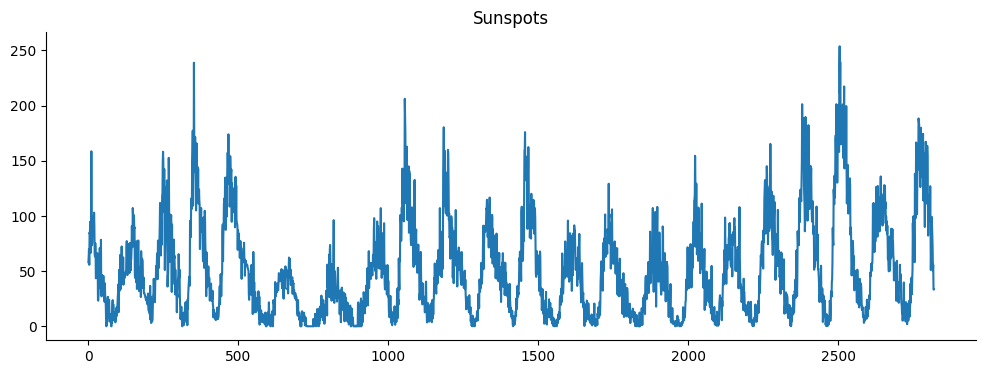

In [ ]:
df['Sunspots'].plot(kind='line', figsize=(12, 4), title='Sunspots')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [ ]:
data = np.array(df.values)
print(data.min(), data.max())

0.0 253.8


In [ ]:
# scaling the data between 0 and 1 using MinMaxScaler from scikit-learn
scaler = MinMaxScaler(feature_range=(0, 1))
data_sc = scaler.fit_transform(data).flatten()
print(data_sc.min(), data_sc.max())

0.0 1.0


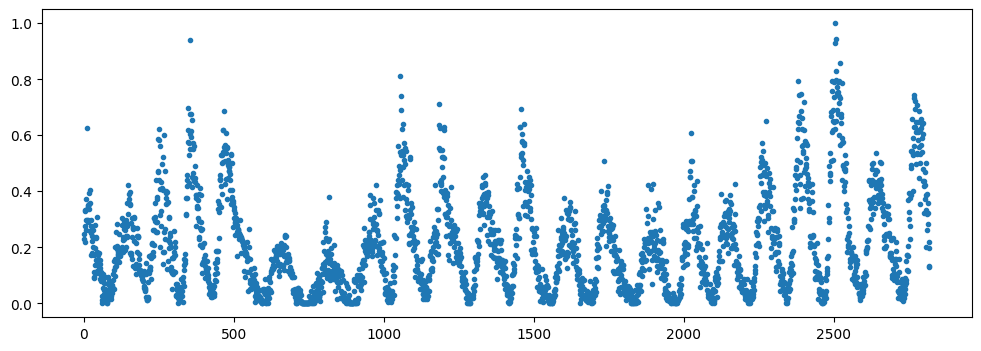

In [ ]:
plt.figure(figsize = (12,4))
plt.plot(data_sc, '.')
plt.show()

In [ ]:
# Splitting data into train and test datasets
n = len(data)
split_percent = 0.8
split = int(n*split_percent)
train_data = data_sc[range(split)]
test_data = data_sc[split:]
print('train_data len:', len(train_data))
print('test_data len:', len(test_data))

train_data len: 2256
test_data len: 564


##Reshaping Data for Keras
The next steps is to prepare the data for Keras model training. The input array should be shaped as: **total_samples x time_steps x features**.

There are many ways of preparing time series data for training. We’ll create input rows with non-overlapping time steps. An example for time steps = 2 is shown in the figure below. Here, time steps denotes the number of previous time steps to use for predicting the next value of the time series data.

<center><img src='https://machinelearningmastery.com/wp-content/uploads/2021/09/rnnCode2-1024x543.png' width=800></center>

The following codes takes a one-dimensional array as input and converts it to the required input X and target Y arrays. We’ll use 12 time_steps for the sunspots dataset as the sunspots generally have a cycle of 12 months. You can experiment with other values of time_steps.

In [ ]:
time_steps = 12
Y_ind = np.arange(time_steps, len(train_data), time_steps)
Y_ind

array([  12,   24,   36,   48,   60,   72,   84,   96,  108,  120,  132,
        144,  156,  168,  180,  192,  204,  216,  228,  240,  252,  264,
        276,  288,  300,  312,  324,  336,  348,  360,  372,  384,  396,
        408,  420,  432,  444,  456,  468,  480,  492,  504,  516,  528,
        540,  552,  564,  576,  588,  600,  612,  624,  636,  648,  660,
        672,  684,  696,  708,  720,  732,  744,  756,  768,  780,  792,
        804,  816,  828,  840,  852,  864,  876,  888,  900,  912,  924,
        936,  948,  960,  972,  984,  996, 1008, 1020, 1032, 1044, 1056,
       1068, 1080, 1092, 1104, 1116, 1128, 1140, 1152, 1164, 1176, 1188,
       1200, 1212, 1224, 1236, 1248, 1260, 1272, 1284, 1296, 1308, 1320,
       1332, 1344, 1356, 1368, 1380, 1392, 1404, 1416, 1428, 1440, 1452,
       1464, 1476, 1488, 1500, 1512, 1524, 1536, 1548, 1560, 1572, 1584,
       1596, 1608, 1620, 1632, 1644, 1656, 1668, 1680, 1692, 1704, 1716,
       1728, 1740, 1752, 1764, 1776, 1788, 1800, 18

In [ ]:
Y = train_data[Y_ind]
Y.shape

(187,)

In [ ]:
rows_x = len(Y)
rows_x

187

In [ ]:
X = train_data[range(time_steps*rows_x)]
X

array([0.2285264 , 0.24665091, 0.27580772, ..., 0.20961387, 0.25295508,
       0.24231678])

In [ ]:
X.shape

(2244,)

In [ ]:
trainX = np.reshape(X, (rows_x, time_steps, 1))
trainX.shape

(187, 12, 1)

In [ ]:
trainX[0]

array([[0.2285264 ],
       [0.24665091],
       [0.27580772],
       [0.21946414],
       [0.33490938],
       [0.32899921],
       [0.37352246],
       [0.26122931],
       [0.29905437],
       [0.29747833],
       [0.6249015 ],
       [0.3356974 ]])

In [ ]:
trainY = Y

In [ ]:
# trainY[0] == train_data[12]
trainY[0]

0.2888100866824271

In [ ]:
train_data[12]

0.2888100866824271

In [ ]:
train_data[0:13]

array([0.2285264 , 0.24665091, 0.27580772, 0.21946414, 0.33490938,
       0.32899921, 0.37352246, 0.26122931, 0.29905437, 0.29747833,
       0.6249015 , 0.3356974 , 0.28881009])

In [ ]:
Yt_ind = np.arange(time_steps, len(test_data), time_steps)
Yt_ind

array([ 12,  24,  36,  48,  60,  72,  84,  96, 108, 120, 132, 144, 156,
       168, 180, 192, 204, 216, 228, 240, 252, 264, 276, 288, 300, 312,
       324, 336, 348, 360, 372, 384, 396, 408, 420, 432, 444, 456, 468,
       480, 492, 504, 516, 528, 540, 552])

In [ ]:
testY = test_data[Yt_ind]
testY

array([3.87706856e-01, 3.16390859e-01, 1.98975571e-01, 1.79669031e-01,
       1.40267928e-01, 4.88573680e-02, 1.45784082e-02, 7.28920410e-02,
       1.87549251e-01, 4.55870764e-01, 4.27501970e-01, 4.69267139e-01,
       4.00315209e-01, 2.36012608e-01, 1.60362490e-01, 1.04412924e-01,
       7.88022065e-04, 9.10165485e-02, 2.89992120e-01, 6.50118203e-01,
       7.97872340e-01, 8.56579984e-01, 5.76438140e-01, 2.28132388e-01,
       1.52482270e-01, 7.80141844e-02, 6.02836879e-02, 6.89519307e-02,
       1.11111111e-01, 4.36958235e-01, 4.79905437e-01, 4.11347518e-01,
       4.39322301e-01, 3.59732072e-01, 2.42316785e-01, 1.71000788e-01,
       1.08747045e-01, 7.44680851e-02, 3.19148936e-02, 6.46178093e-02,
       2.04491726e-01, 6.56422380e-01, 6.28841608e-01, 4.49172577e-01,
       4.38140268e-01, 3.32151300e-01])

In [ ]:
rows_xt = len(Yt)
rows_xt

46

In [ ]:
Xt = test_data[range(time_steps*rows_xt)]
Xt.shape

(552,)

In [ ]:
testX = np.reshape(Xt, (rows_xt, time_steps, 1))
testX.shape

(46, 12, 1)

In [ ]:
# Create RNN Model
K.clear_session()
model = Sequential(name='Simple_RNN')
model.add(SimpleRNN(3, input_shape=(time_steps,1), activation='tanh'))
#model.add(Dropout(0.2))
model.add(Dense(1, 'tanh'))

model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()

Model: "Simple_RNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 3)                 15        
                                                                 
 dense (Dense)               (None, 1)                 4         
                                                                 
Total params: 19 (76.00 Byte)
Trainable params: 19 (76.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Train RNN Model
h = model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20
187/187 - 2s - loss: 0.0244 - 2s/epoch - 9ms/step
Epoch 2/20
187/187 - 0s - loss: 0.0129 - 480ms/epoch - 3ms/step
Epoch 3/20
187/187 - 0s - loss: 0.0109 - 465ms/epoch - 2ms/step
Epoch 4/20
187/187 - 0s - loss: 0.0097 - 456ms/epoch - 2ms/step
Epoch 5/20
187/187 - 0s - loss: 0.0088 - 467ms/epoch - 2ms/step
Epoch 6/20
187/187 - 0s - loss: 0.0080 - 461ms/epoch - 2ms/step
Epoch 7/20
187/187 - 1s - loss: 0.0072 - 671ms/epoch - 4ms/step
Epoch 8/20
187/187 - 1s - loss: 0.0065 - 744ms/epoch - 4ms/step
Epoch 9/20
187/187 - 1s - loss: 0.0061 - 761ms/epoch - 4ms/step
Epoch 10/20
187/187 - 1s - loss: 0.0057 - 759ms/epoch - 4ms/step
Epoch 11/20
187/187 - 1s - loss: 0.0052 - 719ms/epoch - 4ms/step
Epoch 12/20
187/187 - 0s - loss: 0.0050 - 472ms/epoch - 3ms/step
Epoch 13/20
187/187 - 0s - loss: 0.0048 - 486ms/epoch - 3ms/step
Epoch 14/20
187/187 - 0s - loss: 0.0046 - 479ms/epoch - 3ms/step
Epoch 15/20
187/187 - 0s - loss: 0.0044 - 447ms/epoch - 2ms/step
Epoch 16/20
187/187 - 0s - loss: 0.00

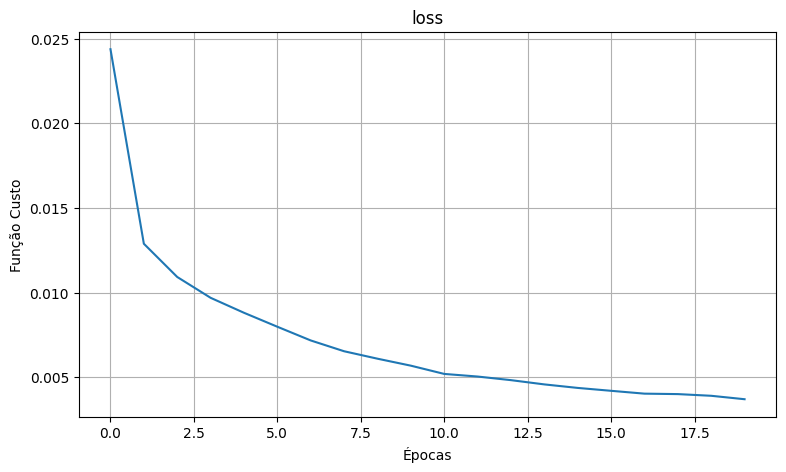

In [ ]:
# plot Loss function
plt.figure(figsize = (9,5))
plt.plot(h.history['loss'])
plt.xlabel('Épocas')
plt.ylabel('Função Custo')
plt.title('loss')
plt.xticks()
plt.yticks()
plt.grid()
plt.show()

In [ ]:
# make predictions
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

2/2 [==============================] - 0s 6ms/step


In [ ]:
# Error of predictions
train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
test_rmse = math.sqrt(mean_squared_error(testY, test_predict))
# Print RMSE (Root Mean Square Error)
print('Train RMSE: %.3f RMSE' % (train_rmse))
print('Test RMSE: %.3f RMSE' % (test_rmse))

Train RMSE: 0.065 RMSE
Test RMSE: 0.103 RMSE


##View the Result
The following codes plots the actual target values and the predicted values. The red line separates the training and test data points

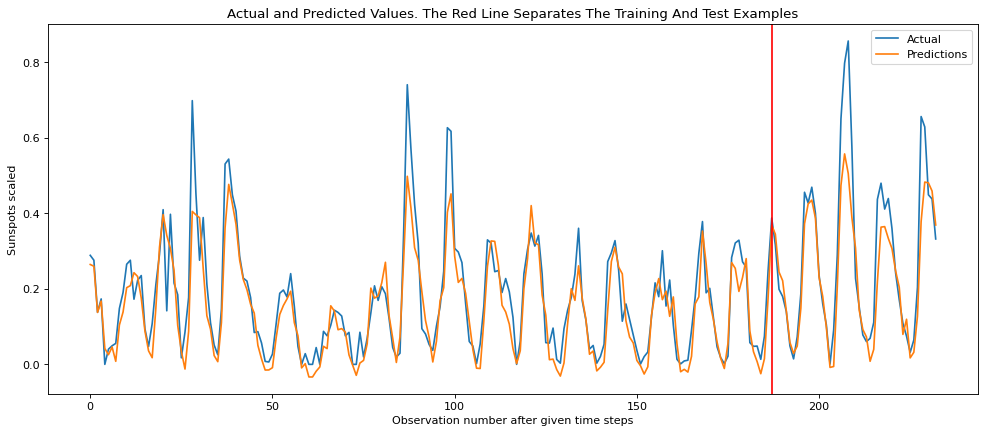

In [ ]:
actual = np.append(trainY, testY)
predictions = np.append(train_predict, test_predict)
rows = len(actual)
plt.figure(figsize=(15, 6), dpi=80)
plt.plot(range(rows), actual)
plt.plot(range(rows), predictions)
plt.axvline(x=len(trainY), color='r')
plt.legend(['Actual', 'Predictions'])
plt.xlabel('Observation number after given time steps')
plt.ylabel('Sunspots scaled')
plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
plt.show()

#Exercícios
1. Mude o número de unidades ocultas (hidden units) para 1, 5, 10 e 50. Compare e comente os resultados dos erros RMSE e os gráficos da função perda e das predições.
1. Modifique o time steps para 3, 6, 20 e 50. Compare e comente os resultados.
1. Inserir mais uma camada oculta SimpleRNN com o mesmo número de unidades da primeira camada, que deve ter o parâmetro `return_sequences=True`. Verificar e comparar os resultados.
1. Incerir técnica de regularização Dropout com taxa de 20%, 30% e 50% depois de cada camada. Comparar os resultados.
1. Montar o banco de dados de treinamento de 12 em 12 amostras com passo de uma unidade para cada novo conjunto de amostras. Desta forma, teremos um train dataset de 2808 x 12 amostras. Comparar os resultados.
1. Utilize o banco de dados com os valores do dolar separando 10% final para teste. Faça a sintonia da rede para melhor se adaptar ao banco de dados. Verifique a eficiência da previsão.

#Referências
[1] https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/

[2] https://machinelearningmastery.com/understanding-simple-recurrent-neural-networks-in-keras/

[3] https://www.tensorflow.org/guide/keras/working_with_rnns

[4] https://www.simplilearn.com/tutorials/deep-learning-tutorial/rnn

[5] https://www.datacamp.com/tutorial/tutorial-for-recurrent-neural-network

[6] https://github.com/bilkosem/simple-rnn_from_scratch